# MilkLab RAG Evaluation

Notebook นี้ประเมิน retrieval pipeline ของ MilkLab RAG chatbot โดยใช้ `menu_kb.md` เป็น knowledge base และวัดผลด้วย `precision@3`, `recall@3`, และ histogram ของ similarity score.

## 1. Import Libraries

นำเข้าไลบรารีสำหรับ evaluation, visualization และ helper จากโปรเจกต์

In [1]:
from __future__ import annotations

from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import app as rag_app

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 120)

/workspaces/milklab-phanuphat/.venv-1/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Documents and Queries

โหลด knowledge base จาก `menu_kb.md` และเตรียมคำถาม evaluation 10 ข้อ

In [2]:
KB_TEXT = rag_app.load_kb_text()
CHUNKS = rag_app.split_markdown_into_chunks(KB_TEXT)
KB_PATH = Path(rag_app.KB_PATH)
RESOURCES = rag_app.build_vector_store(str(KB_PATH), KB_PATH.stat().st_mtime, rag_app.EMBEDDING_MODEL_NAME)

EVAL_QUERIES = [
    "ร้านเปิดกี่โมงและปิดกี่โมง",
    "ร้านเปิดทุกวันไหม",
    "มีเมนูอะไรบ้างที่เป็นนมหมีฮอกไกโด",
    "นมโกโก้บราวนี่ราคาเท่าไหร่",
    "นมเสาวรสราคาเท่าไหร่",
    "นมเย็นใส่วุ้นนมมีส่วนผสมอะไร",
    "คนแพ้ lactose กินได้ไหม",
    "บราวนี่มีสารก่อภูมิแพ้อะไร",
    "ส่งได้ไกลแค่ไหนและค่าส่งเท่าไหร่",
    "จองล่วงหน้าได้ไหมและต้องสั่งก่อนกี่โมง",
]

CHUNK_TITLES = [chunk.title for chunk in CHUNKS]
CHUNK_TITLES

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 620.72it/s]


['เกี่ยวกับร้าน', 'เมนูหลัก', 'Allergen', 'FAQ']

## 3. Create 10 Ground-Truth Questions

กำหนด relevant chunk สำหรับแต่ละคำถามเพื่อใช้คำนวณ precision@3 และ recall@3

In [8]:
GROUND_TRUTH = {
    "ร้านเปิดกี่โมงและปิดกี่โมง": ["เกี่ยวกับร้าน"],
    "ร้านเปิดทุกวันไหม": ["เกี่ยวกับร้าน"],
    "มีเมนูอะไรบ้างที่เป็นนมหมีฮอกไกโด": ["เมนูหลัก"],
    "นมโกโก้บราวนี่ราคาเท่าไหร่": ["เมนูหลัก"],
    "นมเสาวรสราคาเท่าไหร่": ["เมนูหลัก"],
    "นมเย็นใส่วุ้นนมมีส่วนผสมอะไร": ["เมนูหลัก"],
    "คนแพ้ lactose กินได้ไหม": ["Allergen"],
    "บราวนี่มีสารก่อภูมิแพ้อะไร": ["Allergen"],
    "ส่งได้ไกลแค่ไหนและค่าส่งเท่าไหร่": ["FAQ"],
    "จองล่วงหน้าได้ไหมและต้องสั่งก่อนกี่โมง": ["FAQ"],
}

eval_df = pd.DataFrame(
    {
        "question": EVAL_QUERIES,
        "expected_titles": [GROUND_TRUTH[question] for question in EVAL_QUERIES],
    }
)
eval_df

,question,expected_titles
0,ร้านเปิดกี่โมงและปิดกี่โมง,[เกี่ยวกับร้าน]
1,ร้านเปิดทุกวันไหม,[เกี่ยวกับร้าน]
2,มีเมนูอะไรบ้างที่เป็นนมหมีฮอกไกโด,[เมนูหลัก]
3,นมโกโก้บราวนี่ราคาเท่าไหร่,[เมนูหลัก]
4,นมเสาวรสราคาเท่าไหร่,[เมนูหลัก]
5,นมเย็นใส่วุ้นนมมีส่วนผสมอะไร,[เมนูหลัก]
6,คนแพ้ lactose กินได้ไหม,[Allergen]
7,บราวนี่มีสารก่อภูมิแพ้อะไร,[Allergen]
8,ส่งได้ไกลแค่ไหนและค่าส่งเท่าไหร่,[FAQ]
9,จองล่วงหน้าได้ไหมและต้องสั่งก่อนกี่โมง,[FAQ]


## 4. Run Retrieval with Top-k=3

ดึงผลค้นหา top-3 สำหรับแต่ละคำถามและเก็บ similarity score

In [9]:
def evaluate_query(question: str, top_k: int = 3) -> dict:
    trace_id = f"eval-{abs(hash(question)) % 10_000}"
    retrieved = rag_app.retrieve_top_k(
        question,
        trace_id=trace_id,
        resources=RESOURCES,
        top_k=top_k,
    )
    retrieved_titles = [item["title"] for item in retrieved]
    expected_titles = set(GROUND_TRUTH[question])
    hits = [title for title in retrieved_titles if title in expected_titles]

    precision_at_k = len(hits) / top_k if top_k else 0.0
    recall_at_k = len(hits) / len(expected_titles) if expected_titles else 0.0
    max_score = max([item["score"] for item in retrieved], default=0.0)

    return {
        "question": question,
        "expected_titles": list(expected_titles),
        "retrieved_titles": retrieved_titles,
        "hits": hits,
        "precision@3": precision_at_k,
        "recall@3": recall_at_k,
        "scores": [item["score"] for item in retrieved],
        "max_score": max_score,
    }


results = [evaluate_query(question) for question in EVAL_QUERIES]
retrieval_df = pd.DataFrame(results)
retrieval_df

2026-08-10 14:59:48,595 | INFO | start span=retrieve_top_k trace_id=eval-4023 attrs={'top_k': 3, 'query': 'ร้านเปิดกี่โมงและปิดกี่โมง'}
2026-08-10 14:59:48,628 | INFO | end span=retrieve_top_k trace_id=eval-4023 elapsed_ms=32.95 attrs={'top_k': 3, 'query': 'ร้านเปิดกี่โมงและปิดกี่โมง'}
2026-08-10 14:59:48,629 | INFO | start span=retrieve_top_k trace_id=eval-8317 attrs={'top_k': 3, 'query': 'ร้านเปิดทุกวันไหม'}
2026-08-10 14:59:48,658 | INFO | end span=retrieve_top_k trace_id=eval-8317 elapsed_ms=28.85 attrs={'top_k': 3, 'query': 'ร้านเปิดทุกวันไหม'}
2026-08-10 14:59:48,659 | INFO | start span=retrieve_top_k trace_id=eval-542 attrs={'top_k': 3, 'query': 'มีเมนูอะไรบ้างที่เป็นนมหมีฮอกไกโด'}
2026-08-10 14:59:48,694 | INFO | end span=retrieve_top_k trace_id=eval-542 elapsed_ms=34.19 attrs={'top_k': 3, 'query': 'มีเมนูอะไรบ้างที่เป็นนมหมีฮอกไกโด'}
2026-08-10 14:59:48,695 | INFO | start span=retrieve_top_k trace_id=eval-5512 attrs={'top_k': 3, 'query': 'นมโกโก้บราวนี่ราคาเท่าไหร่'}
2026-08-1

,question,expected_titles,retrieved_titles,hits,precision@3,recall@3,scores,max_score
0,ร้านเปิดกี่โมงและปิดกี่โมง,[เกี่ยวกับร้าน],"[เกี่ยวกับร้าน, FAQ, Allergen]",[เกี่ยวกับร้าน],0.333333,1.0,"[0.41847941279411316, 0.2950769066810608, 0.121061772108078]",0.418479
1,ร้านเปิดทุกวันไหม,[เกี่ยวกับร้าน],"[เกี่ยวกับร้าน, FAQ, Allergen]",[เกี่ยวกับร้าน],0.333333,1.0,"[0.44680461287498474, 0.25614050030708313, 0.24215540289878845]",0.446805
2,มีเมนูอะไรบ้างที่เป็นนมหมีฮอกไกโด,[เมนูหลัก],"[Allergen, เมนูหลัก, เกี่ยวกับร้าน]",[เมนูหลัก],0.333333,1.0,"[0.5454773306846619, 0.5127061605453491, 0.39989420771598816]",0.545477
3,นมโกโก้บราวนี่ราคาเท่าไหร่,[เมนูหลัก],"[เมนูหลัก, FAQ, Allergen]",[เมนูหลัก],0.333333,1.0,"[0.5203554630279541, 0.39932841062545776, 0.25543057918548584]",0.520355
4,นมเสาวรสราคาเท่าไหร่,[เมนูหลัก],"[เมนูหลัก, เกี่ยวกับร้าน, Allergen]",[เมนูหลัก],0.333333,1.0,"[0.759746789932251, 0.5403785705566406, 0.5072507262229919]",0.759747
5,นมเย็นใส่วุ้นนมมีส่วนผสมอะไร,[เมนูหลัก],"[เมนูหลัก, Allergen, เกี่ยวกับร้าน]",[เมนูหลัก],0.333333,1.0,"[0.5338658094406128, 0.5305211544036865, 0.46825045347213745]",0.533866
6,คนแพ้ lactose กินได้ไหม,[Allergen],"[Allergen, เมนูหลัก, เกี่ยวกับร้าน]",[Allergen],0.333333,1.0,"[0.6435909271240234, 0.4096943140029907, 0.3011343777179718]",0.643591
7,บราวนี่มีสารก่อภูมิแพ้อะไร,[Allergen],"[Allergen, เมนูหลัก, เกี่ยวกับร้าน]",[Allergen],0.333333,1.0,"[0.19901269674301147, 0.12360750883817673, 0.04335927590727806]",0.199013
8,ส่งได้ไกลแค่ไหนและค่าส่งเท่าไหร่,[FAQ],"[FAQ, เมนูหลัก, เกี่ยวกับร้าน]",[FAQ],0.333333,1.0,"[0.4985837936401367, 0.33456072211265564, 0.18087056279182434]",0.498584
9,จองล่วงหน้าได้ไหมและต้องสั่งก่อนกี่โมง,[FAQ],"[FAQ, เกี่ยวกับร้าน, เมนูหลัก]",[FAQ],0.333333,1.0,"[0.4494604468345642, 0.325003981590271, 0.1029692068696022]",0.449460


## 5. Calculate Precision@3 and Recall@3

คำนวณค่าเฉลี่ยของ metric ทั้งหมดจากคำถามทั้ง 10 ข้อ

In [10]:
summary = {
    "precision@3": retrieval_df["precision@3"].mean(),
    "recall@3": retrieval_df["recall@3"].mean(),
}
summary_df = pd.DataFrame([summary])
summary_df

,precision@3,recall@3
0,0.333333,1.0


## 6. Plot Similarity Score Histogram

แสดงการกระจายของ similarity score จากผล retrieval

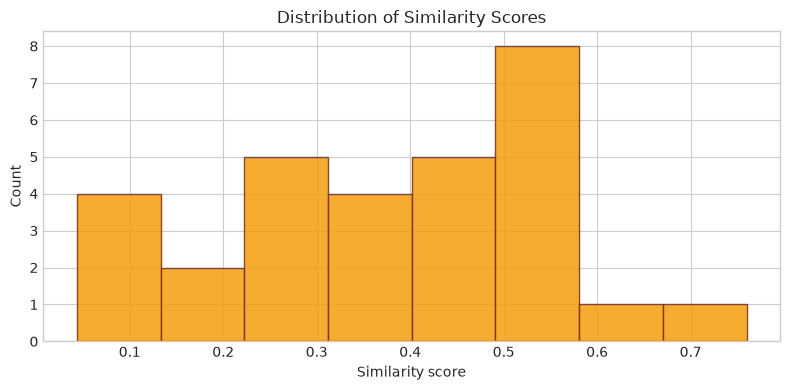

In [11]:
all_scores = [score for row in results for score in row["scores"]]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(all_scores, bins=8, color="#f59e0b", edgecolor="#7c2d12", alpha=0.85)
ax.set_title("Distribution of Similarity Scores")
ax.set_xlabel("Similarity score")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## 7. Display Evaluation Summary

สรุปผลรายคำถามและผลรวมของการประเมิน

In [12]:
display_columns = [
    "question",
    "expected_titles",
    "retrieved_titles",
    "hits",
    "precision@3",
    "recall@3",
    "max_score",
]

detailed_df = retrieval_df[display_columns].copy()
detailed_df["precision@3"] = detailed_df["precision@3"].round(3)
detailed_df["recall@3"] = detailed_df["recall@3"].round(3)
detailed_df["max_score"] = detailed_df["max_score"].round(3)

display(detailed_df)
display(summary_df.round(3))

print(f"Overall precision@3: {summary['precision@3']:.3f}")
print(f"Overall recall@3: {summary['recall@3']:.3f}")

,question,expected_titles,retrieved_titles,hits,precision@3,recall@3,max_score
0,ร้านเปิดกี่โมงและปิดกี่โมง,[เกี่ยวกับร้าน],"[เกี่ยวกับร้าน, FAQ, Allergen]",[เกี่ยวกับร้าน],0.333,1.0,0.418
1,ร้านเปิดทุกวันไหม,[เกี่ยวกับร้าน],"[เกี่ยวกับร้าน, FAQ, Allergen]",[เกี่ยวกับร้าน],0.333,1.0,0.447
2,มีเมนูอะไรบ้างที่เป็นนมหมีฮอกไกโด,[เมนูหลัก],"[Allergen, เมนูหลัก, เกี่ยวกับร้าน]",[เมนูหลัก],0.333,1.0,0.545
3,นมโกโก้บราวนี่ราคาเท่าไหร่,[เมนูหลัก],"[เมนูหลัก, FAQ, Allergen]",[เมนูหลัก],0.333,1.0,0.520
4,นมเสาวรสราคาเท่าไหร่,[เมนูหลัก],"[เมนูหลัก, เกี่ยวกับร้าน, Allergen]",[เมนูหลัก],0.333,1.0,0.760
5,นมเย็นใส่วุ้นนมมีส่วนผสมอะไร,[เมนูหลัก],"[เมนูหลัก, Allergen, เกี่ยวกับร้าน]",[เมนูหลัก],0.333,1.0,0.534
6,คนแพ้ lactose กินได้ไหม,[Allergen],"[Allergen, เมนูหลัก, เกี่ยวกับร้าน]",[Allergen],0.333,1.0,0.644
7,บราวนี่มีสารก่อภูมิแพ้อะไร,[Allergen],"[Allergen, เมนูหลัก, เกี่ยวกับร้าน]",[Allergen],0.333,1.0,0.199
8,ส่งได้ไกลแค่ไหนและค่าส่งเท่าไหร่,[FAQ],"[FAQ, เมนูหลัก, เกี่ยวกับร้าน]",[FAQ],0.333,1.0,0.499
9,จองล่วงหน้าได้ไหมและต้องสั่งก่อนกี่โมง,[FAQ],"[FAQ, เกี่ยวกับร้าน, เมนูหลัก]",[FAQ],0.333,1.0,0.449


,precision@3,recall@3
0,0.333,1.0


Overall precision@3: 0.333
Overall recall@3: 1.000
